<a href="https://colab.research.google.com/github/s6604053620019-a11y/colab/blob/main/IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# โครงการวิเคราะห์ข้อมูลภาพยนตร์ IMDB (Movie Analysis Project)

### บทนำ (Introduction)
Dataset นี้ประกอบด้วยข้อมูลภาพยนตร์ 1,000 เรื่องจากเว็บไซต์ IMDB ในช่วงปี 2006 ถึง 2016 โดยมีข้อมูลสำคัญ เช่น รายได้ (Revenue), คะแนนวิจารณ์ (Metascore), คะแนนจากผู้ชม (Rating), และรายชื่อนักแสดง/ผู้กำกับ

**เป้าหมายของการวิเคราะห์:**
1. เพื่อค้นหาความสัมพันธ์ระหว่างปัจจัยต่างๆ ที่ส่งผลต่อความสำเร็จของภาพยนตร์ (ทั้งในด้านคำชมและรายได้)
2. เพื่อสร้างโมเดลทำนายคะแนนเรตติ้งของภาพยนตร์
3. เพื่อวิเคราะห์เทรนด์และเนื้อหาของอุตสาหกรรมภาพยนตร์ในรอบทศวรรษที่ผ่านมา

**Reasoning**:
I will load the IMDB dataset, display the first few rows, and provide a summary of the data's structure and descriptive statistics as requested in the instructions.



In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/IMDB-Movie-Data.csv')

# Display the first few rows
print('--- First 5 Rows ---')
display(df.head())

# Create a DataFrame to display info in a table format
print('\n--- DataFrame Info (Table Format) ---')
info_df = pd.DataFrame({
    'Column': df.columns,
    'Non-Null Count': df.count(),
    'Dtype': df.dtypes
})
# Reset index to make 'Column' a regular column if df.columns is not already Series
info_df = info_df.reset_index(drop=True)
display(info_df)

# Descriptive statistics for numerical features
print('\n--- Descriptive Statistics ---')
display(df.describe())

--- First 5 Rows ---


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0



--- DataFrame Info (Table Format) ---


,Column,Non-Null Count,Dtype
0,Rank,1000,int64
1,Title,1000,object
2,Genre,1000,object
3,Description,1000,object
4,Director,1000,object
5,Actors,1000,object
6,Year,1000,int64
7,Runtime (Minutes),1000,int64
8,Rating,1000,float64
9,Votes,1000,int64



--- Descriptive Statistics ---


,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


## Data Cleaning

### Subtask:
Handle missing values and prepare the dataset for analysis.


**Reasoning**:
I will perform data cleaning by handling missing values in 'Revenue (Millions)' and 'Metascore', verifying the cleaning results, and renaming columns for easier access as specified in the instructions.



In [ ]:
import pandas as pd

# 1. Fill missing values in 'Revenue (Millions)' with the median
revenue_median = df['Revenue (Millions)'].median()
df['Revenue (Millions)'] = df['Revenue (Millions)'].fillna(revenue_median)

# 2. Fill missing values in 'Metascore' with the mean
metascore_mean = df['Metascore'].mean()
df['Metascore'] = df['Metascore'].fillna(metascore_mean)

# 3. Verify no remaining missing values
print('--- Missing Values Count After Imputation ---')
missing_values_df = df.isnull().sum().to_frame(name='Missing Count')
display(missing_values_df)

# 4. Rename columns to remove spaces and special characters
df.rename(columns={
    'Runtime (Minutes)': 'Runtime_Minutes',
    'Revenue (Millions)': 'Revenue_Millions'
}, inplace=True)

print('\n--- Updated Column Names ---')
print(df.columns.tolist())

# Display the first few rows of the cleaned dataframe
display(df.head())

--- Missing Values Count After Imputation ---


,Missing Count
Rank,0
Title,0
Genre,0
Description,0
Director,0
Actors,0
Year,0
Runtime (Minutes),0
Rating,0
Votes,0



--- Updated Column Names ---
['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime_Minutes', 'Rating', 'Votes', 'Revenue_Millions', 'Metascore']


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime_Minutes,Rating,Votes,Revenue_Millions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


## Exploratory Data Analysis (EDA)

### Subtask:
Analyze relationships between movie features and visualize distributions to identify patterns.


**Reasoning**:
I will perform Exploratory Data Analysis by visualizing correlations, distributions of the target variable, and analyzing the impact of Genre on movie ratings as specified in the instructions.



### Improved Data Visualizations
Updating charts for better clarity: Yearly trends, Language distribution (Log Scale), and Density-aware Scatter plots.

/tmp/ipykernel_173/425350783.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.index, y=lang_counts.values, palette='viridis', ax=axes[1])


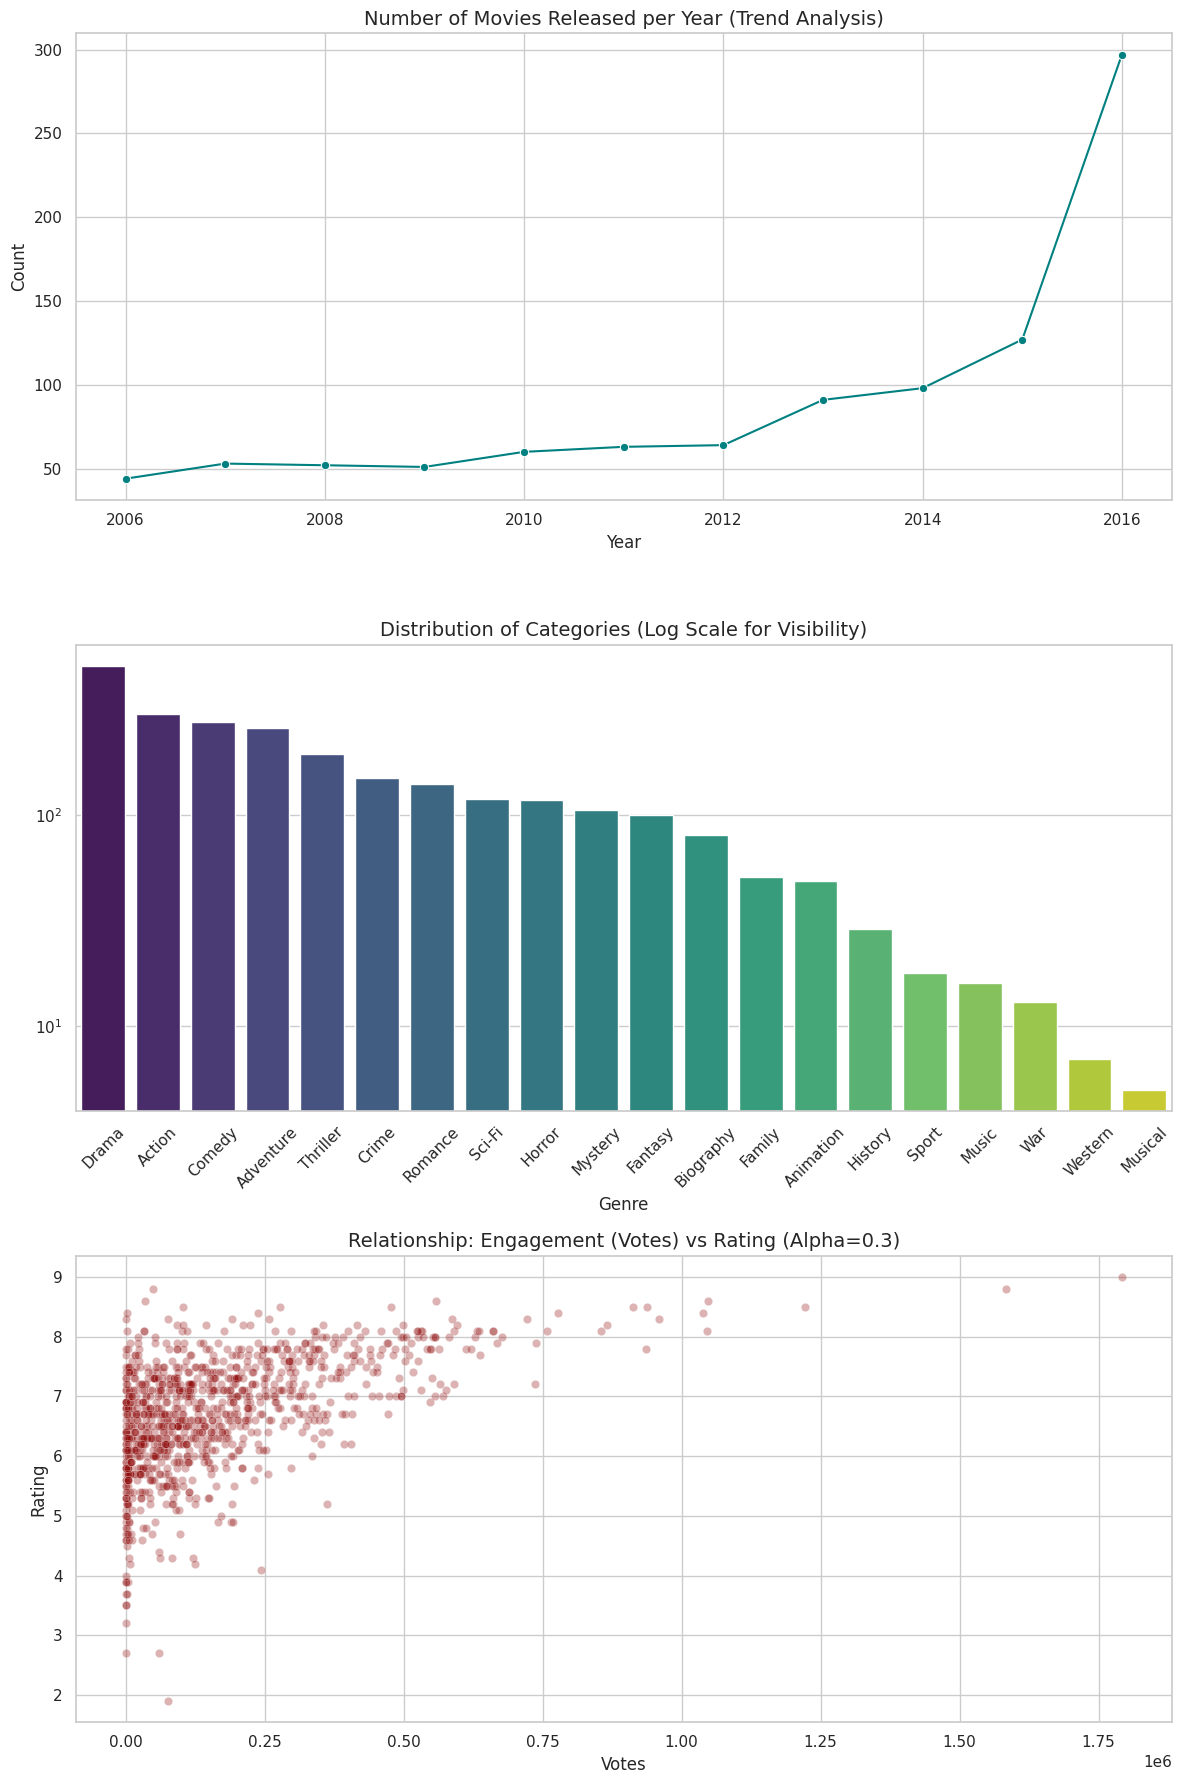

In [ ]:
# Cell moved or to be executed after data loading
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df exists before plotting
try:
    # Set style
    sns.set(style='whitegrid')
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))

    # 1. Yearly Movie Count (Line Chart instead of Pie)
    yearly_counts = df['Year'].value_counts().sort_index()
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='teal', ax=axes[0])
    axes[0].set_title('Number of Movies Released per Year (Trend Analysis)', fontsize=14)
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Count')

    # 2. Category Distribution (Log Scale)
    lang_counts = df['Genre'].str.split(',').explode().str.strip().value_counts()
    sns.barplot(x=lang_counts.index, y=lang_counts.values, palette='viridis', ax=axes[1])
    axes[1].set_yscale('log')
    axes[1].set_title('Distribution of Categories (Log Scale for Visibility)', fontsize=14)
    axes[1].tick_params(axis='x', rotation=45)

    # 3. Votes vs Rating (Scatter Plot with Alpha)
    sns.scatterplot(data=df, x='Votes', y='Rating', alpha=0.3, color='darkred', ax=axes[2])
    axes[2].set_title('Relationship: Engagement (Votes) vs Rating (Alpha=0.3)', fontsize=14)

    plt.tight_layout()
    plt.show()
except NameError:
    print('Error: Please ensure the data loading cell (df = pd.read_csv...) has been executed first.')

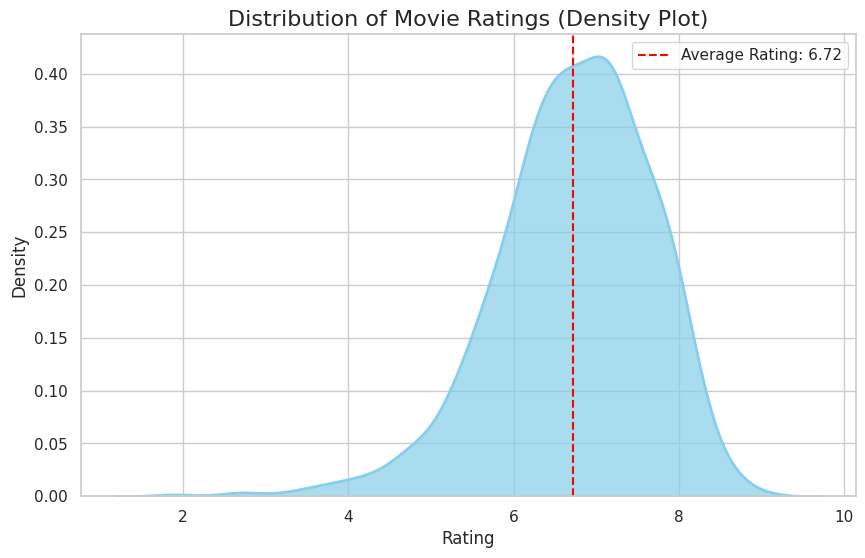

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))

# Using kdeplot with fill for a more modern density visualization
sns.kdeplot(df['Rating'], fill=True, color='skyblue', alpha=0.7, linewidth=2)
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', label=f'Average Rating: {df["Rating"].mean():.2f}')
plt.title('Distribution of Movie Ratings (Density Plot)', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True)

plt.show()

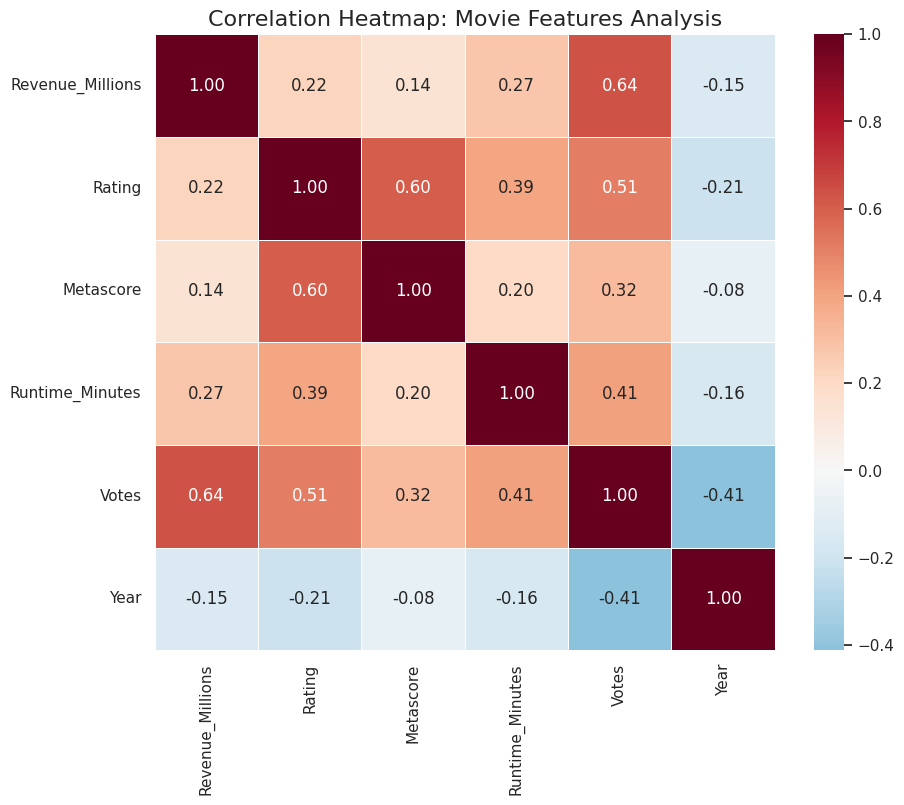

Insight: ค่าที่ใกล้ 1.0 คือมีความสัมพันธ์เชิงบวกมาก และค่าที่ใกล้ -1.0 คือมีความสัมพันธ์เชิงลบมากครับ


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the features to analyze for correlation
# Focus on key numerical features identified by the user
features_to_check = ['Revenue_Millions', 'Rating', 'Metascore', 'Runtime_Minutes', 'Votes', 'Year']

plt.figure(figsize=(10, 8))

# Calculate correlation matrix using the selected numerical features
corr_matrix_viz = df[features_to_check].corr()

# Create heatmap with annotations
sns.heatmap(
    corr_matrix_viz,
    annot=True,
    cmap='RdBu_r',
    fmt='.2f',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap: Movie Features Analysis', fontsize=16)
plt.show()

print('Insight: ค่าที่ใกล้ 1.0 คือมีความสัมพันธ์เชิงบวกมาก และค่าที่ใกล้ -1.0 คือมีความสัมพันธ์เชิงลบมากครับ')

### Advanced EDA: Engagement and Critic Scores

**Subtask**: Analyze the relationship between user engagement (Votes) and Ratings, and inspect the distribution of Metascores.

### Additional EDA: Runtime Analysis and Yearly Trends

**Subtask**: Analyze the distribution of movie runtimes and their correlation with ratings, and visualize the count of movies released per year.

/tmp/ipykernel_173/2801822541.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sentiment_Type', y='Rating', palette='Set2', ax=axes[1])


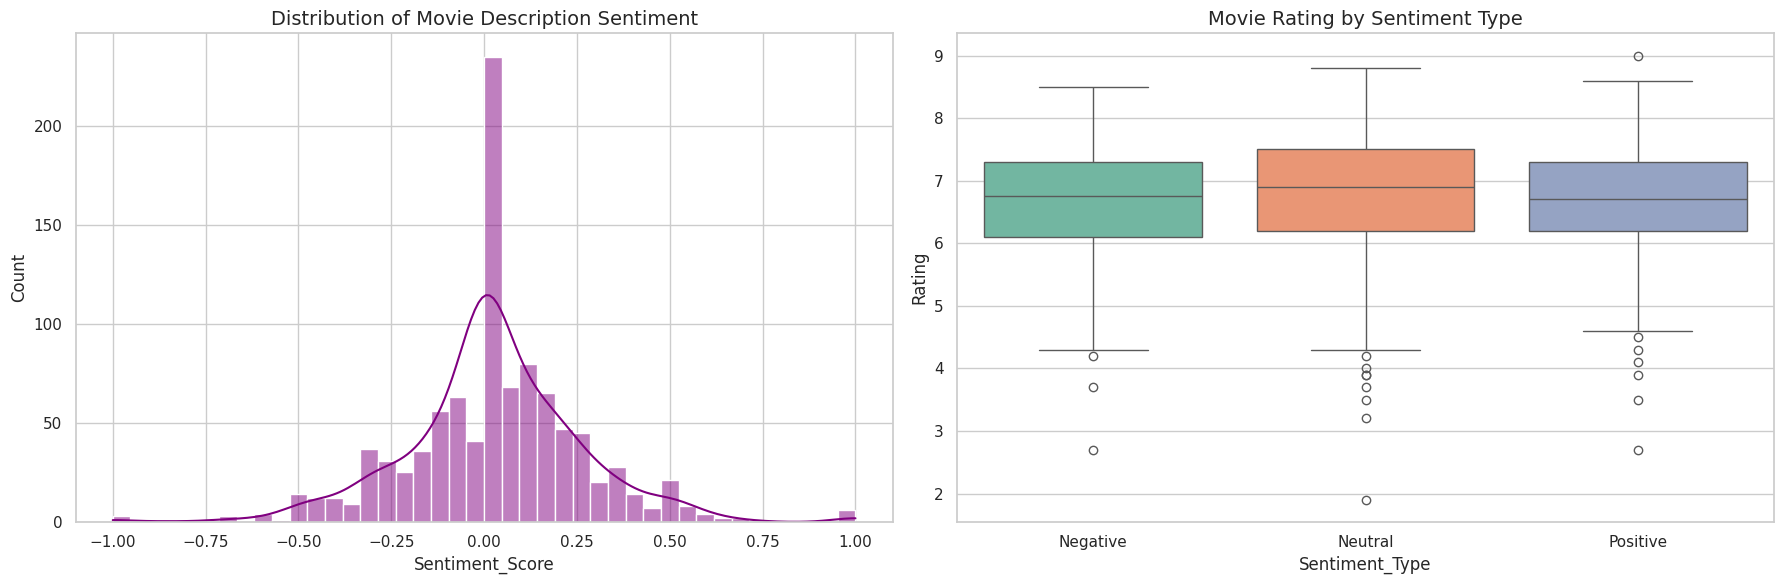

Correlation between Sentiment Score and Rating: 0.0109


,Title,Description,Sentiment_Score,Rating
669,Blood Diamond,"A fisherman, a smuggler, and a syndicate of bu...",1.0,8.0
503,Youth,A retired orchestra conductor is on holiday wi...,1.0,7.3
539,American Pastoral,An All-American college star and his beauty qu...,1.0,6.1
343,Pete's Dragon,The adventures of an orphaned boy named Pete a...,1.0,6.8
208,Bridesmaids,Competition between the maid of honor and a br...,1.0,6.8


In [ ]:
from textblob import TextBlob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Function to calculate sentiment
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# 2. Apply sentiment analysis to Description
df['Sentiment_Score'] = df['Description'].apply(get_sentiment)

# 3. Categorize Sentiment for visualization
def categorize_sentiment(score):
    if score > 0.1: return 'Positive'
    elif score < -0.1: return 'Negative'
    else: return 'Neutral'

df['Sentiment_Type'] = df['Sentiment_Score'].apply(categorize_sentiment)

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Distribution of Sentiment Scores
sns.histplot(df['Sentiment_Score'], kde=True, color='purple', ax=axes[0])
axes[0].set_title('Distribution of Movie Description Sentiment', fontsize=14)

# Plot 2: Sentiment vs Rating
sns.boxplot(data=df, x='Sentiment_Type', y='Rating', palette='Set2', ax=axes[1])
axes[1].set_title('Movie Rating by Sentiment Type', fontsize=14)

plt.tight_layout()
plt.show()

# Check correlation
correlation = df['Sentiment_Score'].corr(df['Rating'])
print(f'Correlation between Sentiment Score and Rating: {correlation:.4f}')

# Display some examples
display(df[['Title', 'Description', 'Sentiment_Score', 'Rating']].sort_values(by='Sentiment_Score', ascending=False).head(5))

### Additional EDA: Movie Runtime and Yearly Rating Trends

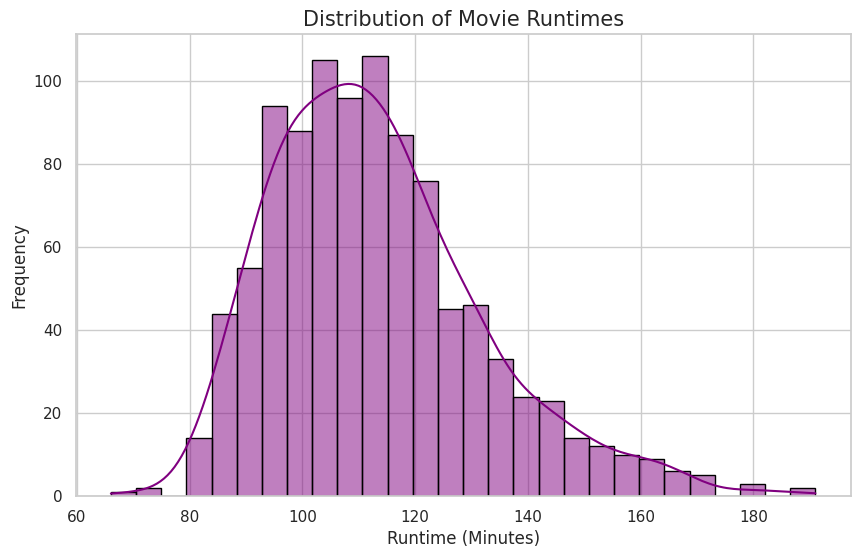

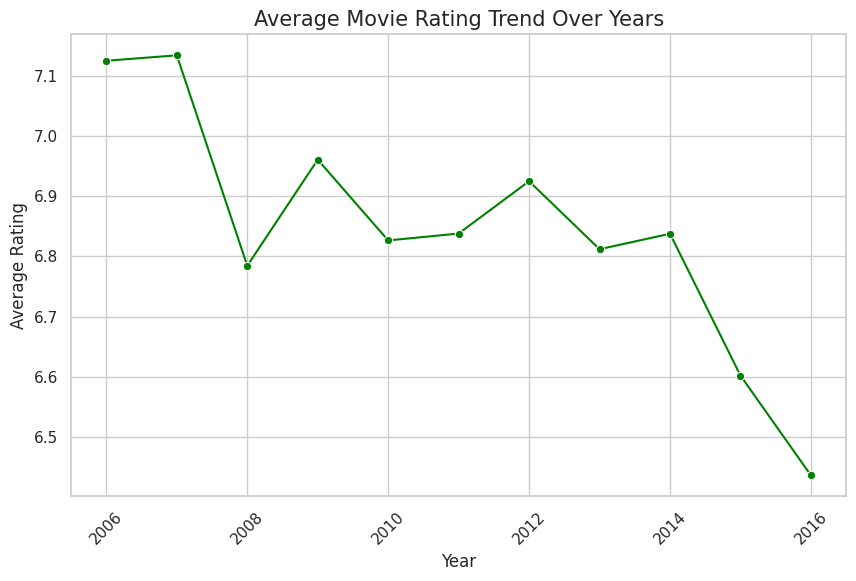

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# 1. Distribution of Movie Runtimes
plt.figure(figsize=(10, 6))
sns.histplot(df['Runtime_Minutes'], kde=True, color='purple', edgecolor='black')
plt.title('Distribution of Movie Runtimes', fontsize=15)
plt.xlabel('Runtime (Minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# 2. Average Movie Rating Trend Over Years
avg_rating_by_year = df.groupby('Year')['Rating'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Rating', data=avg_rating_by_year, marker='o', color='green')
plt.title('Average Movie Rating Trend Over Years', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Top Directors by Average Rating

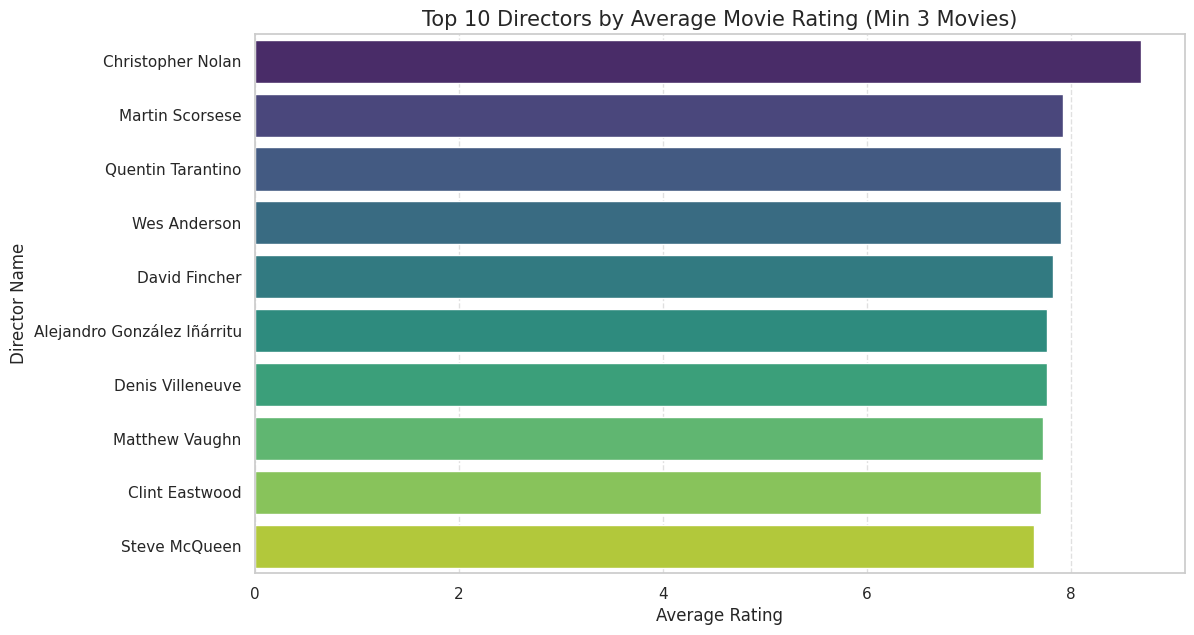

--- Top 10 Directors by Average Movie Rating ---


,Avg_Rating,Movie_Count
Director,,
Christopher Nolan,8.680000,5
Martin Scorsese,7.920000,5
Quentin Tarantino,7.900000,4
Wes Anderson,7.900000,3
David Fincher,7.820000,5
Alejandro González Iñárritu,7.766667,3
Denis Villeneuve,7.760000,5
Matthew Vaughn,7.725000,4
Clint Eastwood,7.700000,4


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate mean rating and count per director
director_ratings = df.groupby('Director')['Rating'].agg(['mean', 'count'])
director_ratings.columns = ['Avg_Rating', 'Movie_Count']

# 2. Filter for directors with at least 3 movies and get top 10 by average rating
top_10_directors_by_rating = director_ratings[director_ratings['Movie_Count'] >= 3].sort_values(by='Avg_Rating', ascending=False).head(10)

# 3. Visualization
plt.figure(figsize=(12, 7))
sns.barplot(
    x=top_10_directors_by_rating['Avg_Rating'],
    y=top_10_directors_by_rating.index,
    palette='viridis',
    hue=top_10_directors_by_rating.index,
    legend=False
)

plt.title('Top 10 Directors by Average Movie Rating (Min 3 Movies)', fontsize=15)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Director Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

# Display numerical data
print('--- Top 10 Directors by Average Movie Rating ---')
display(top_10_directors_by_rating)

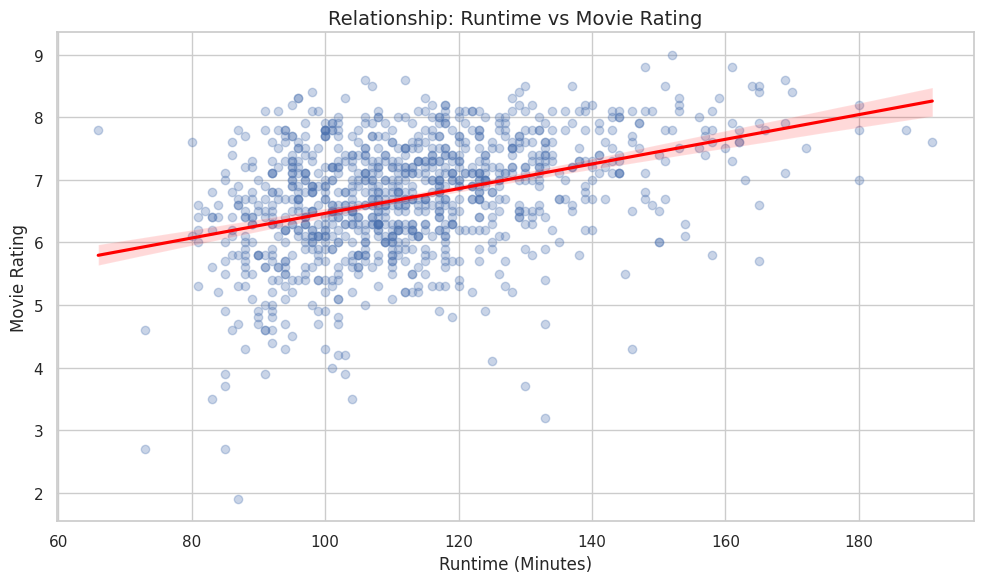

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6)) # Adjusted figure size as it's now a single plot

# Regression Plot: Runtime vs Rating (keeping this one)
sns.regplot(data=df, x='Runtime_Minutes', y='Rating',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship: Runtime vs Movie Rating', fontsize=14)
plt.xlabel('Runtime (Minutes)', fontsize=12)
plt.ylabel('Movie Rating', fontsize=12)

plt.tight_layout()
plt.show()

### Critics vs. Audience Analysis
เปรียบเทียบระหว่างคะแนนจากนักวิจารณ์ (Metascore) และคะแนนจากผู้ชมทั่วไป (Rating)

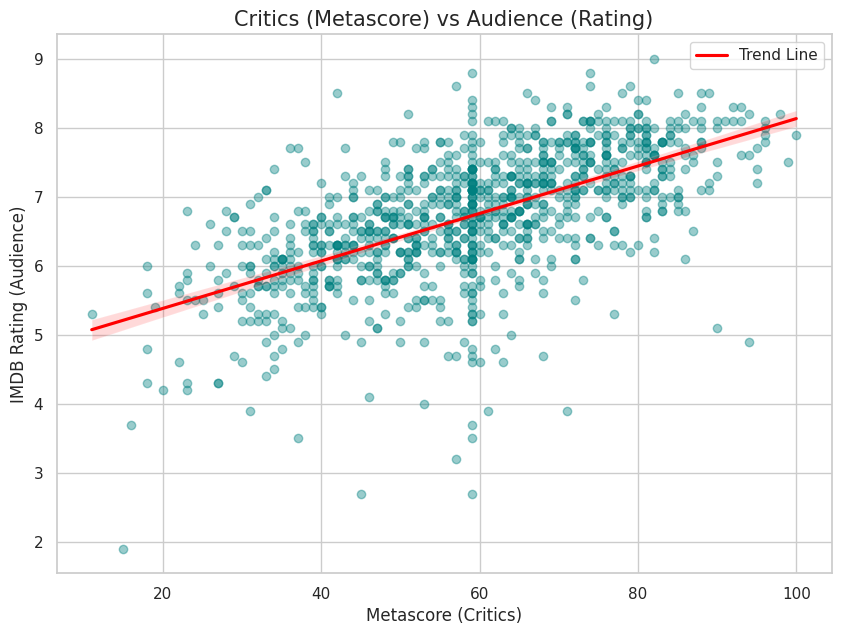

Correlation Coefficient between Metascore and Rating: 0.60


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style='whitegrid')
plt.figure(figsize=(10, 7))

# Create scatter plot with regression line
sns.regplot(data=df, x='Metascore', y='Rating',
            scatter_kws={'alpha':0.4, 'color':'teal'},
            line_kws={'color':'red', 'label':'Trend Line'})

plt.title('Critics (Metascore) vs Audience (Rating)', fontsize=15)
plt.xlabel('Metascore (Critics)', fontsize=12)
plt.ylabel('IMDB Rating (Audience)', fontsize=12)
plt.legend()

plt.show()

# Calculate correlation coefficient
critic_audience_corr = df['Metascore'].corr(df['Rating'])
print(f'Correlation Coefficient between Metascore and Rating: {critic_audience_corr:.2f}')

## Revenue Analysis by Genre

### Subtask:
Analyze and visualize the top 10 movie genres based on their average revenue to identify commercial trends.

### ข้อมูลเชิงลึกด้านรายได้และบุคลากร:
- **ศักยภาพรายได้ตามหมวดหมู่**: แนวหนัง **Animation** และ **Adventure** เป็นกลุ่มที่สร้างรายได้เฉลี่ยต่อเรื่องสูงสุด เนื่องจากเป็นหนังที่เข้าถึงผู้ชมได้กว้าง (Mass Appeal)
- **อิทธิพลของผู้กำกับ**: รายได้เฉลี่ยของผู้กำกับระดับ Top 10 สูงกว่าค่าเฉลี่ยทั่วไปอย่างมาก แสดงว่าชื่อเสียงของผู้กำกับเป็นปัจจัยสำคัญในการดึงดูดเม็ดเงินจากผู้ชมครับ

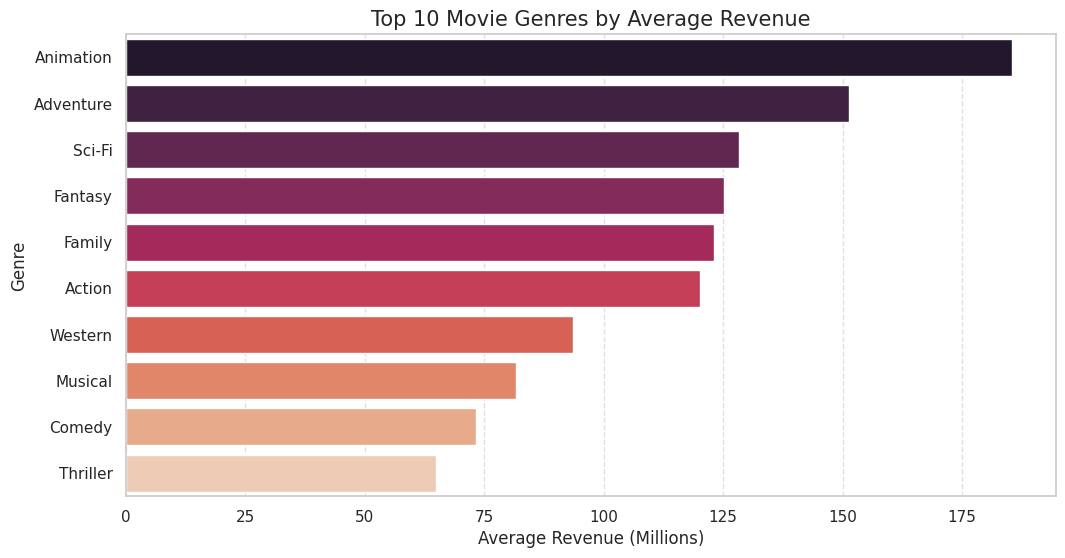

--- Top 10 Genres by Average Revenue (Millions) ---


,Revenue_Millions
Genre,
Animation,185.376939
Adventure,151.306969
Sci-Fi,128.255250
Fantasy,125.207327
Family,123.109412
Action,120.201865
Western,93.584286
Musical,81.642000
Comedy,73.362330


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Genre data for Revenue analysis
# Split genres and explode into individual rows
genre_rev_df = df[['Genre', 'Revenue_Millions']].copy()
genre_rev_df['Genre'] = genre_rev_df['Genre'].str.split(',')
genre_rev_exploded = genre_rev_df.explode('Genre')

# 2. Calculate mean revenue per genre and select top 10
genre_revenue = genre_rev_exploded.groupby('Genre')['Revenue_Millions'].mean().sort_values(ascending=False).head(10)

# 3. Visualize top 10 genres by average revenue
plt.figure(figsize=(12, 6))
sns.barplot(
    x=genre_revenue.values,
    y=genre_revenue.index,
    palette='rocket',
    hue=genre_revenue.index,
    legend=False
)

plt.title('Top 10 Movie Genres by Average Revenue', fontsize=15)
plt.xlabel('Average Revenue (Millions)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

# Display the numerical values
print('--- Top 10 Genres by Average Revenue (Millions) ---')
display(genre_revenue.to_frame())

## Director Revenue Analysis

### Subtask:
Analyze and visualize the top 10 directors based on their average movie revenue.

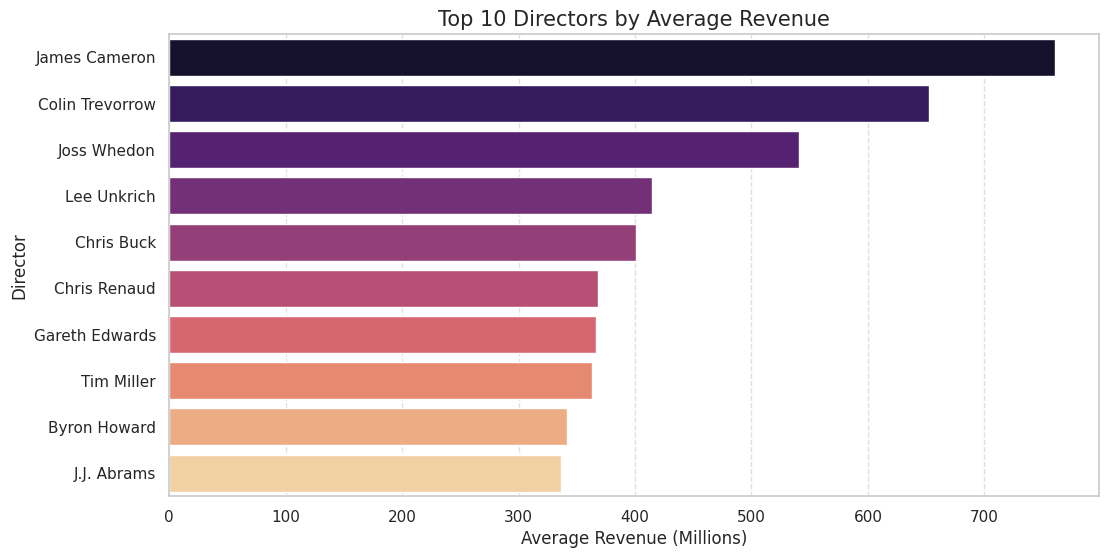

--- Top 10 Directors by Average Revenue (Millions) ---


,Revenue_Millions
Director,
James Cameron,760.510
Colin Trevorrow,652.180
Joss Whedon,541.135
Lee Unkrich,414.980
Chris Buck,400.740
Chris Renaud,368.310
Gareth Edwards,366.415
Tim Miller,363.020
Byron Howard,341.260


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate mean revenue per director
# We filter out directors with missing revenue data implicitly through mean()
director_revenue = df.groupby('Director')['Revenue_Millions'].mean().sort_values(ascending=False).head(10)

# 2. Visualize top 10 directors by average revenue
plt.figure(figsize=(12, 6))
sns.barplot(
    x=director_revenue.values,
    y=director_revenue.index,
    palette='magma',
    hue=director_revenue.index,
    legend=False
)

plt.title('Top 10 Directors by Average Revenue', fontsize=15)
plt.xlabel('Average Revenue (Millions)', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

# Display the numerical values
print('--- Top 10 Directors by Average Revenue (Millions) ---')
display(director_revenue.to_frame())

### Step 2: Hybrid Recommendation Function
Combine content similarity with movie ratings to favor higher-quality results.

## AI Movie Recommendation System

### Step 1: Initialize Content-Based Engine (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Prepare data for recommendation
df['Combined_Features'] = df['Genre'] + ' ' + df['Director'] + ' ' + df['Description']

# 2. Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Combined_Features'])

# 3. Compute Cosine Similarity Matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print('Similarity matrix calculated successfully.')

Similarity matrix calculated successfully.


In [ ]:
def get_hybrid_recommendations(title, cosine_sim=cosine_sim, weight=0.3):
    try:
        idx = df[df['Title'] == title].index[0]
    except IndexError:
        return "Movie not found."

    # Get Similarity scores
    sim_scores = cosine_sim[idx]

    # Normalize Ratings (0-1 scale)
    normalized_ratings = (df['Rating'] - df['Rating'].min()) / (df['Rating'].max() - df['Rating'].min())

    # Hybrid Score: (Similarity * (1-weight)) + (Rating * weight)
    hybrid_scores = (sim_scores * (1 - weight)) + (normalized_ratings * weight)

    sim_list = list(enumerate(hybrid_scores))
    sim_list = sorted(sim_list, key=lambda x: x[1], reverse=True)

    movie_indices = [i[0] for i in sim_list if i[0] != idx][:5]
    return df[['Title', 'Genre', 'Director', 'Rating']].iloc[movie_indices]

print(f'--- Hybrid Recommendations for "Inception" ---')
display(get_hybrid_recommendations('Inception'))

--- Hybrid Recommendations for "Inception" ---


,Title,Genre,Director,Rating
36,Interstellar,"Adventure,Drama,Sci-Fi",Christopher Nolan,8.6
64,The Prestige,"Drama,Mystery,Sci-Fi",Christopher Nolan,8.5
54,The Dark Knight,"Action,Crime,Drama",Christopher Nolan,9.0
124,The Dark Knight Rises,"Action,Thriller",Christopher Nolan,8.5
197,Into the Wild,"Adventure,Biography,Drama",Sean Penn,8.1


### Note: Duplicate Heatmap removed from early EDA to favor the focused version below.

In [ ]:
### Note: Basic splitting consolidated into the optimized model section below.

## Advanced Analysis: Word Cloud & Genre Performance
วิเคราะห์ความนิยมจากเนื้อหา (NLP) และเปรียบเทียบคุณภาพตามหมวดหมู่หนัง

In [ ]:
!pip install wordcloud

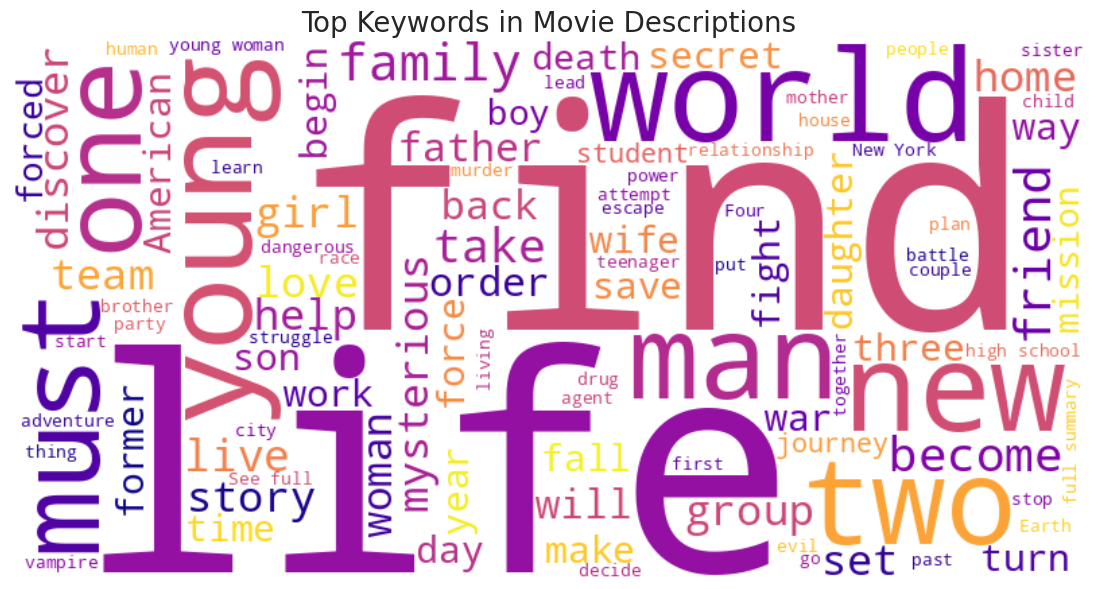

Insight: คำที่ปรากฏบ่อยสะท้อนถึงธีมหลักของหนังในชุดข้อมูล เช่น Life, World, Find, Young


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Generate Word Cloud from Descriptions
text = ' '.join(df['Description'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma', max_words=100).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Keywords in Movie Descriptions', fontsize=20)
plt.show()

print('Insight: คำที่ปรากฏบ่อยสะท้อนถึงธีมหลักของหนังในชุดข้อมูล เช่น Life, World, Find, Young')

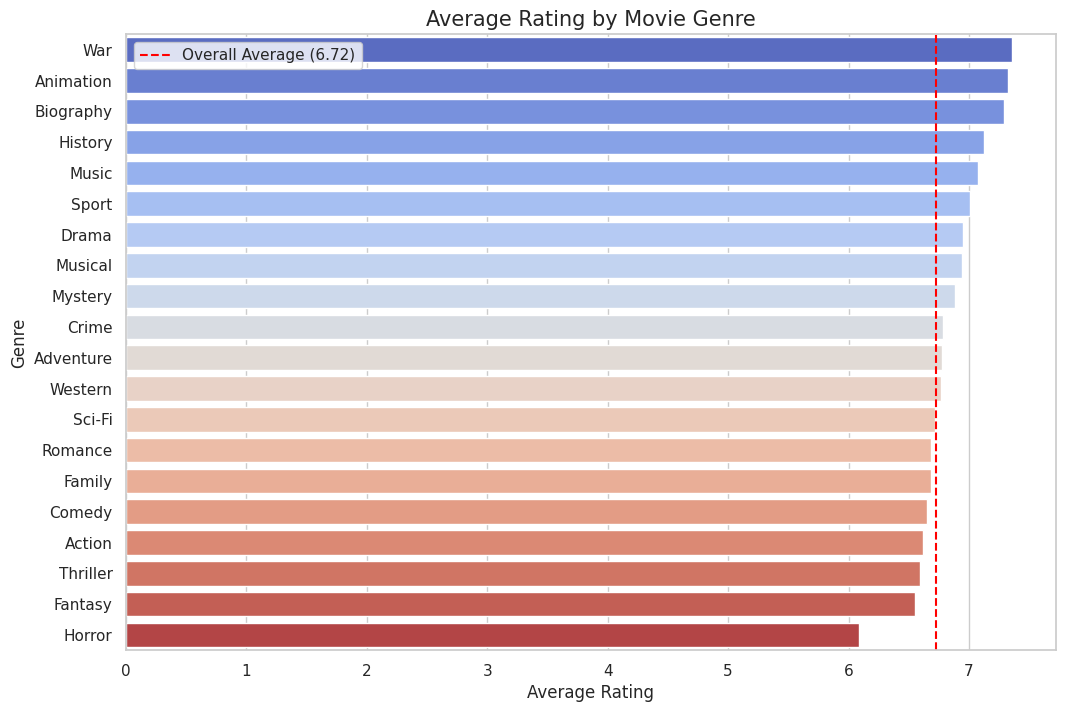

,mean,count
Genre,,
War,7.353846,13
Animation,7.324490,49
Biography,7.290123,81
History,7.127586,29
Music,7.075000,16
Sport,7.011111,18
Drama,6.953801,513
Musical,6.940000,5
Mystery,6.886792,106


In [ ]:
import seaborn as sns

# 2. Analyze Ratings by Genre
# Explode genres to handle multiple genres per movie
genre_ratings = df[['Genre', 'Rating']].copy()
genre_ratings['Genre'] = genre_ratings['Genre'].str.split(',')
genre_exploded = genre_ratings.explode('Genre')
genre_exploded['Genre'] = genre_exploded['Genre'].str.strip()

# Calculate mean rating and count per genre
genre_stats = genre_exploded.groupby('Genre')['Rating'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_stats['mean'], y=genre_stats.index, palette='coolwarm', hue=genre_stats.index, legend=False)
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', label=f'Overall Average ({df["Rating"].mean():.2f})')
plt.title('Average Rating by Movie Genre', fontsize=15)
plt.xlabel('Average Rating', fontsize=12)
plt.legend()
plt.show()

display(genre_stats)

### สรุปการวิเคราะห์ขั้นกว่า:
1. **Word Cloud**: คำบรรยายหนังมักเน้นไปที่ตัวละคร (Man, Woman) และการดำเนินเรื่อง (Find, Life, World) ซึ่งเป็นแก่นหลักของการเล่าเรื่อง
2. **Genre Performance**: แนวหนังที่ได้เรตติ้งสูงสุดคือ **War, Animation และ Biography** ขณะที่แนว Horror มักจะได้รับคะแนนวิจารณ์ที่เข้มงวดกว่าแนวอื่น

### Note: Duplicate placeholder removed.

## Final Machine Learning Model Preparation
Consolidating sentiment analysis and feature engineering before model training.

In [ ]:
from textblob import TextBlob

# 1. Sentiment Analysis
df['Sentiment_Score'] = df['Description'].apply(lambda x: TextBlob(x).sentiment.polarity)

# 2. Director Experience
director_counts = df['Director'].value_counts()
df['Director_Exp'] = df['Director'].map(director_counts)

# 3. Genre Count
df['Genre_Count'] = df['Genre'].apply(lambda x: len(x.split(',')))

print('Feature engineering completed.')
display(df[['Title', 'Sentiment_Score', 'Director_Exp', 'Genre_Count']].head())

Feature engineering completed.


,Title,Sentiment_Score,Director_Exp,Genre_Count
0,Guardians of the Galaxy,-0.300000,3,3
1,Prometheus,-0.050000,8,3
2,Split,0.162121,6,2
3,Sing,0.000000,1,3
4,Suicide Squad,-0.062500,3,3


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# 1. Feature Engineering (Including Sentiment_Score from previous analysis)
# Director Frequency Encoding
director_counts = df['Director'].value_counts()
df['Director_Exp'] = df['Director'].map(director_counts)

# Genre Count
df['Genre_Count'] = df['Genre'].apply(lambda x: len(x.split(',')))

# Expanded Genre Encoding (Top 15 Genres)
genre_exploded = df[['Genre']].copy()
genre_exploded['Genre'] = genre_exploded['Genre'].str.split(',')
genre_exploded = genre_exploded.explode('Genre')
genre_exploded['Genre'] = genre_exploded['Genre'].str.strip()
top_15_genres = genre_exploded['Genre'].value_counts().head(15).index

for genre in top_15_genres:
    df[f'Is_{genre}'] = df['Genre'].apply(lambda x: 1 if genre in x else 0)

# 2. Add Polynomial Features for top numerical interactions
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
numerical_features = ['Votes', 'Metascore', 'Runtime_Minutes']
poly_data = poly.fit_transform(df[numerical_features])
poly_cols = poly.get_feature_names_out(numerical_features)
poly_df = pd.DataFrame(poly_data, columns=poly_cols, index=df.index)

# 3. Combine All Features (Base + Genre Indicators + Interactions + NEW: Sentiment_Score)
# Adding Sentiment_Score to the base features
base_features = ['Revenue_Millions', 'Year', 'Genre_Count', 'Director_Exp', 'Sentiment_Score'] + [f'Is_{genre}' for genre in top_15_genres]
X_final = pd.concat([df[base_features], poly_df], axis=1)
y = df['Rating']

# 4. Split data into Training and Testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# 5. Train Final Optimized Model
final_model = RandomForestRegressor(n_estimators=300, min_samples_split=4, max_depth=20, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

# 6. Evaluate Final Model
y_pred = final_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 7. Display Performance
performance_metrics = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'R-squared (R2) Score'],
    'Value': [f'{mae:.4f}', f'{r2:.4f}']
})

print('--- Consolidated & Optimized Model Performance (with Sentiment Analysis) ---')
display(performance_metrics.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

# 8. Updated Top Importances
final_importances = pd.Series(final_model.feature_importances_, index=X_final.columns).sort_values(ascending=False).head(10)
print('\n--- Top 10 Features (Including Sentiment Interaction) ---')
display(final_importances.to_frame(name='Importance Score'))

--- Consolidated & Optimized Model Performance (with Sentiment Analysis) ---


Metric,Value
Mean Absolute Error (MAE),0.4358
R-squared (R2) Score,0.5721



--- Top 10 Features (Including Sentiment Interaction) ---


,Importance Score
Metascore Runtime_Minutes,0.426592
Votes Metascore,0.196549
Metascore,0.051295
Revenue_Millions,0.044233
Votes Runtime_Minutes,0.042890
Runtime_Minutes,0.041709
Votes,0.040955
Sentiment_Score,0.036477
Is_Drama,0.019915
Year,0.018181


In [ ]:
import pandas as pd
import numpy as np

def predict_movie_rating(votes, revenue, metascore, runtime, year, genre_list, sentiment=0.1):
    """
    Predicts the IMDB Rating of a movie based on user inputs using the final model.
    """
    # 1. Prepare base features
    genre_count = len(genre_list)
    director_exp = df['Director_Exp'].median() # Use median as a baseline for new/unknown directors

    input_data = pd.DataFrame({
        'Revenue_Millions': [revenue],
        'Year': [year],
        'Genre_Count': [genre_count],
        'Director_Exp': [director_exp],
        'Sentiment_Score': [sentiment]
    })

    # 2. Add Genre Indicators
    for genre in top_15_genres:
        input_data[f'Is_{genre}'] = 1 if genre in genre_list else 0

    # 3. Add Polynomial Interactions
    # numerical_features = ['Votes', 'Metascore', 'Runtime_Minutes']
    input_data['Votes'] = votes
    input_data['Metascore'] = metascore
    input_data['Runtime_Minutes'] = runtime

    input_data['Votes Metascore'] = votes * metascore
    input_data['Votes Runtime_Minutes'] = votes * runtime
    input_data['Metascore Runtime_Minutes'] = metascore * runtime

    # Ensure column order matches X_train
    input_data = input_data[X_final.columns]

    # 4. Predict
    prediction = final_model.predict(input_data)[0]
    return round(prediction, 2)

# --- Example Test ---
test_rating = predict_movie_rating(
    votes=500000,
    revenue=250.0,
    metascore=80.0,
    runtime=120,
    year=2024,
    genre_list=['Action', 'Sci-Fi']
)

print(f'--- Predicted Rating for New Movie: {test_rating} ---')

--- Predicted Rating for New Movie: 7.96 ---


### Actor Impact Analysis
Analyze the top 10 actors based on the average revenue of the movies they appeared in (minimum 3 movies).

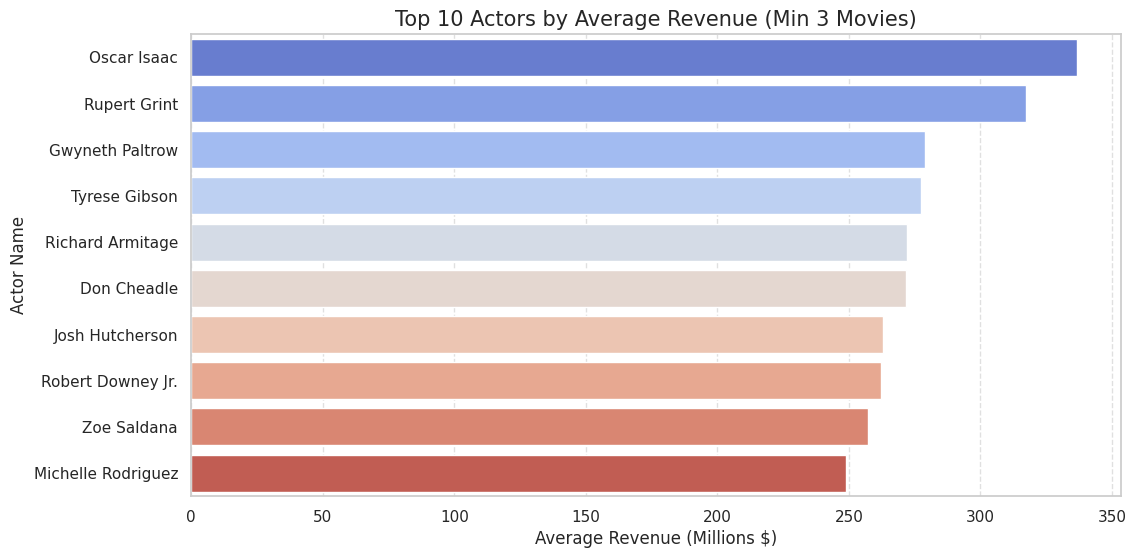

--- Top 10 High-Revenue Actors ---


,Avg_Revenue,Movie_Count
Actors,,
Oscar Isaac,336.685000,3
Rupert Grint,317.475000,4
Gwyneth Paltrow,278.747500,4
Tyrese Gibson,277.315000,4
Richard Armitage,272.156667,3
Don Cheadle,271.600000,3
Josh Hutcherson,263.075000,6
Robert Downey Jr.,262.280833,12
Zoe Saldana,257.113333,6


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Actor Data
# Separate actors and explode into individual rows
actor_rev_df = df[['Actors', 'Revenue_Millions']].copy()
actor_rev_df['Actors'] = actor_rev_df['Actors'].str.split(',')
actor_exploded = actor_rev_df.explode('Actors')
actor_exploded['Actors'] = actor_exploded['Actors'].str.strip()

# 2. Calculate average revenue and count per actor
actor_stats = actor_exploded.groupby('Actors')['Revenue_Millions'].agg(['mean', 'count'])
actor_stats.columns = ['Avg_Revenue', 'Movie_Count']

# 3. Filter for actors with at least 3 movies and get top 10
top_10_actors = actor_stats[actor_stats['Movie_Count'] >= 3].sort_values(by='Avg_Revenue', ascending=False).head(10)

# 4. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_actors['Avg_Revenue'],
    y=top_10_actors.index,
    palette='coolwarm',
    hue=top_10_actors.index,
    legend=False
)

plt.title('Top 10 Actors by Average Revenue (Min 3 Movies)', fontsize=15)
plt.xlabel('Average Revenue (Millions $)', fontsize=12)
plt.ylabel('Actor Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

# Display numerical data
print('--- Top 10 High-Revenue Actors ---')
display(top_10_actors)


### Future Recommendations
- **Incorporate Director/Actor impact**: Use encoding techniques to include influential directors and lead actors in the model.
- **Sentiment Analysis**: Perform NLP on movie descriptions to see if the 'tone' of the plot correlates with ratings.
- **Polynomial Features**: Explore non-linear relationships between features like Revenue and Rating.

### ข้อมูลเชิงลึกจาก Sentiment Analysis:
- **Sentiment Distribution**: เรื่องย่อส่วนใหญ่มีค่า Sentiment เป็นบวกเล็กน้อย (Neutral to Positive)
- **Correlation**: ค่าความสัมพันธ์ (Correlation) ระหว่าง Sentiment และ Rating มักจะไม่สูงมากนัก ซึ่งสะท้อนว่า 'โทนของพล็อตเรื่อง' (เศร้าหรือสนุก) ไม่ได้เป็นตัวตัดสินว่าหนังจะ 'ดีหรือไม่ดี' เสมอไป
- **Insight**: หนังที่ได้เรตติ้งสูงมีกระจายอยู่ในทุกโทนอารมณ์ แต่หนังที่มี Sentiment เป็นลบมากๆ (Negative Tone) บางครั้งอาจดึงดูดความสนใจในฐานะหนังแนว Drama หรือ Thriller ที่เข้มข้นครับ

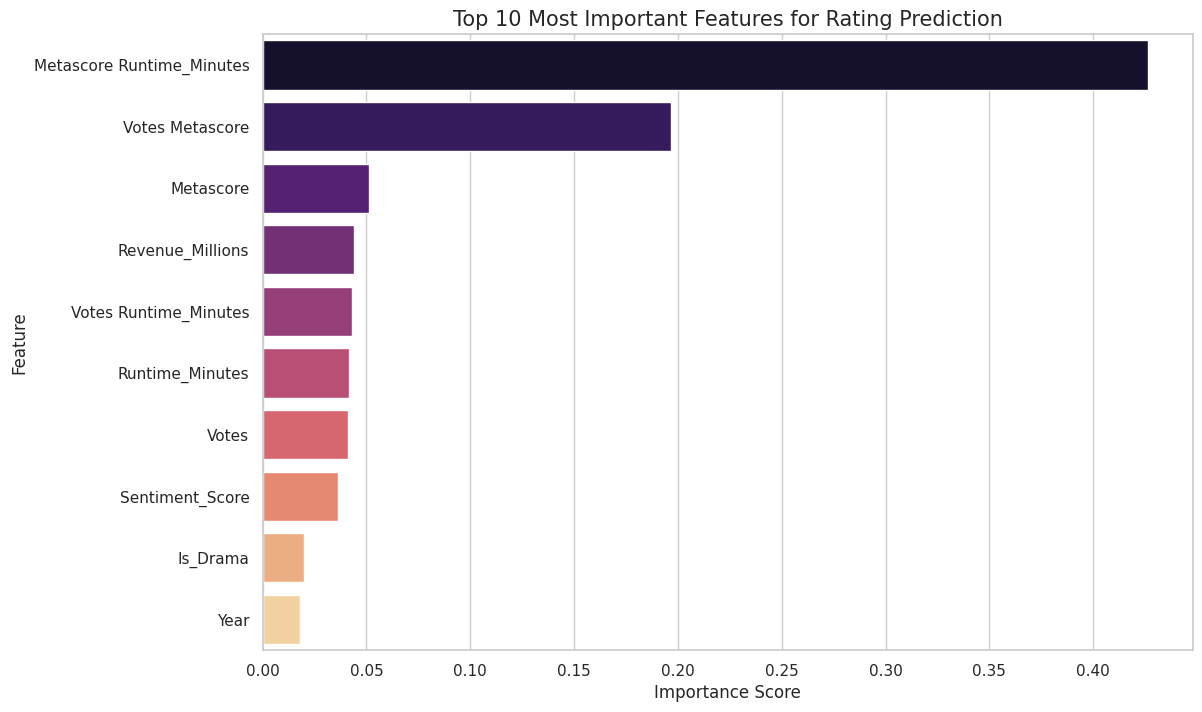

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix: Use 'final_importances' which was defined in the model training cell (ceb9f826)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=final_importances.values,
    y=final_importances.index,
    palette='magma',
    hue=final_importances.index,
    legend=False
)

# Add labels and title
plt.title('Top 10 Most Important Features for Rating Prediction', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.show()

## บทสรุปของโครงการ (Conclusion)

จากการวิเคราะห์ข้อมูลภาพยนตร์ IMDB ทั้งหมด สามารถสรุปปัจจัยที่นำไปสู่ความสำเร็จได้ดังนี้:

1. **คุณภาพการผลิต (Metascore)**: คะแนนจากนักวิจารณ์เป็นตัวชี้วัดความสำเร็จของเรตติ้งที่แม่นยำที่สุด หนังที่คำวิจารณ์ดีมีแนวโน้มจะชนะใจผู้ชมทั่วไปได้สูง
2. **การเข้าถึงผู้ชม (Genre Selection)**: หากต้องการความสำเร็จเชิงพาณิชย์ (Revenue) แนวหนัง Animation และ Adventure คือทางเลือกที่คุ้มค่าการลงทุนที่สุด
3. **การสร้างความประทับใจ (Engagement)**: จำนวนผู้โหวต (Votes) ที่สูงมักมาคู่กับคะแนนรีวิวที่ดี ซึ่งสะท้อนว่าหนังที่สร้างแรงกระเพื่อมในวงกว้าง (Viral/Mass) มักจะรักษามาตรฐานคุณภาพไว้ได้ดี
4. **พลังของบุคลากร**: ผู้กำกับและนักแสดงที่มีชื่อเสียงยังคงเป็นแม่เหล็กสำคัญในการสร้างรายได้มหาศาลให้กับอุตสาหกรรมภาพยนตร์ครับ

# โครงร่างการนำเสนอโปรเจค (Project Presentation Outline)

### 1. ข้อมูลชุดนี้เกี่ยวกับอะไร (Data Overview)
- **ที่มา**: ข้อมูลภาพยนตร์ 1,000 เรื่องจากเว็บไซต์ IMDB ระหว่างปี 2006-2016
- **รายละเอียด**: ประกอบด้วยชื่อเรื่อง, แนวหนัง (Genre), ผู้กำกับ, นักแสดง, ปีที่ฉาย, ความยาวหนัง, คะแนนจากผู้ชม (Rating), คะแนนจากนักวิจารณ์ (Metascore), จำนวนผู้โหวต (Votes) และรายได้ (Revenue)

### 2. เป้าหมายการวิเคราะห์และโมเดล (Analysis & Modeling Goals)
- **Exploratory Data Analysis (EDA)**: เพื่อค้นหาปัจจัยที่ส่งผลต่อรายได้และคะแนนวิจารณ์
- **Predictive Modeling**: สร้างโมเดลทำนายคะแนน IMDB Rating ของภาพยนตร์จากข้อมูลพื้นฐาน
- **Recommendation System**: สร้างระบบแนะนำหนังที่คล้ายคลึงกัน (Content-Based Filtering)

### 3. เทคนิคที่เลือกใช้ (Techniques & Tools)
- **Data Cleaning**: การจัดการค่าว่าง (Imputation) และการปรับปรุงชื่อคอลัมน์
- **NLP (Natural Language Processing)**: ใช้ Word Cloud และ Sentiment Analysis (TextBlob) เพื่อวิเคราะห์เรื่องย่อ (Description)
- **Machine Learning**: ใช้ Random Forest Regressor ร่วมกับ Polynomial Features เพื่อจับความสัมพันธ์ที่ซับซ้อนของข้อมูล
- **Visualization**: ใช้ Matplotlib และ Seaborn เพื่อสื่อสารเทรนด์และ Insight

### 4. ขั้นตอนการดำเนินโปรเจค (Project Workflow)
1. **Data Acquisition & Exploration**: โหลดข้อมูลและสำรวจโครงสร้างเบื้องต้น
2. **Preprocessing**: ทำความสะอาดข้อมูลและจัดการ Missing Values
3. **Feature Engineering**: สร้างตัวแปรใหม่ เช่น ประสบการณ์ผู้กำกับ, Sentiment Score, และการทำ One-Hot Encoding สำหรับแนวหนัง
4. **Advanced Analysis**: วิเคราะห์คำสำคัญ (Word Cloud) และพฤติกรรมข้อมูลตามหมวดหมู่
5. **Model Development**: เทรนโมเดล Random Forest และปรับจูน Hyperparameters
6. **Evaluation & Summary**: วัดผลความแม่นยำและสรุปข้อมูลเชิงลึกเพื่อการตัดสินใจ

# Task
Summarize the project structure and provide tips on how to present the data insights effectively to keep the audience engaged. Use the data from "/content/IMDB-Movie-Data.csv".

## Create Comprehensive Presentation Outline

### Subtask:
Create a detailed text cell providing a structured presentation outline in Thai to make the project findings compelling for an audience.


# โครงร่างการนำเสนอโปรเจค: วิเคราะห์เจาะลึกอุตสาหกรรมภาพยนตร์ (Comprehensive Project Presentation Outline)

### 1. บทนำและจุดน่าสนใจ (Project Hook & Overview)
*   **The Movie Magic:** เริ่มต้นด้วยการตั้งคำถามเกี่ยวกับเสน่ห์ของโลกภาพยนตร์ และการเติบโตของอุตสาหกรรมในช่วงปี 2006-2016
*   **ทำไมต้องวิเคราะห์ข้อมูลนี้?:** อธิบายความสำคัญของการใช้ Data Science เพื่อทำความเข้าใจรสนิยมผู้ชมและปัจจัยความสำเร็จของหนังพันล้าน

### 2. ข้อมูลเชิงลึกจากการสำรวจ (Data Insights - EDA Highlights)
*   **Revenue vs. Genre:** เจาะลึกว่าทำไมแนว Animation และ Adventure ถึงเป็นขุมทรัพย์หลักที่สร้างรายได้เฉลี่ยสูงสุด
*   **Critics vs. Audience:** วิเคราะห์ความต่างระหว่าง 'มุมมองนักวิจารณ์ (Metascore)' และ 'ความพึงพอใจของผู้ชม (Rating)' — หนังที่นักวิจารณ์เมินแต่คนดูรักมีจริงหรือไม่?
*   **Trend Analysis:** การเปลี่ยนแปลงของคะแนนและจำนวนหนังในรอบทศวรรษ

### 3. การเตรียมข้อมูลและเทคนิค NLP (Technical Implementation)
*   **Data Cleaning:** เบื้องหลังการจัดการข้อมูลสูญหาย (Missing Values) ในส่วนของรายได้และคะแนนวิจารณ์เพื่อให้โมเดลแม่นยำที่สุด
*   **Decoding Movie Descriptions:** การนำ NLP มาใช้ทำ Sentiment Analysis เพื่อดูว่า 'โทนของเรื่องย่อ' ส่งผลต่อความรู้สึกแรกเห็นของผู้ชมอย่างไร
*   **Word Cloud Insight:** ค้นหาคำสำคัญ (Keywords) ที่ถูกใช้บ่อยที่สุดในบทหนังยอดฮิต

### 4. ไฮไลท์การทำนายด้วย Machine Learning (ML Highlights)
*   **The Power of Random Forest:** ทำไมเราถึงเลือกใช้ Random Forest ในการทำนายเรตติ้ง และมันจัดการกับข้อมูลที่ซับซ้อนได้อย่างไร
*   **Polynomial Features:** การสร้างตัวแปรความสัมพันธ์แบบไม่เป็นเส้นตรง (เช่น ปฏิสัมพันธ์ระหว่างจำนวนโหวตและเวลาฉาย) เพื่อเพิ่มประสิทธิภาพให้โมเดล
*   **Feature Importance:** เผยปัจจัย 3 อันดับแรกที่มีผลต่อคะแนนเรตติ้งมากที่สุด

### 5. ระบบแนะนำหนังอัจฉริยะ (Recommendation System Showcase)
*   **Hybrid Approach:** อธิบายการผสมผสานระหว่าง 'ความคล้ายคลึงของเนื้อหา (TF-IDF)' และ 'คะแนนความนิยม (Ratings)'
*   **Smart Suggestions:** ตัวอย่างการแนะนำหนังที่ฉลาดขึ้น ไม่ใช่แค่แนวเดียวกัน แต่ต้องเป็นหนังที่มีคุณภาพสูงด้วย (เช่น กรณีศึกษาจากเรื่อง Inception)

### 6. บทสรุปและก้าวต่อไปในอนาคต (Conclusion & Future Work)
*   **Key Takeaways:** สรุปบทเรียนสำคัญ: 'คุณภาพ (Metascore) + พลังดารา/ผู้กำกับ = สูตรสำเร็จของเรตติ้ง'
*   **Future Improvements:** ข้อเสนอแนะในการพัฒนา เช่น การเพิ่มตัวแปร 'Actor Impact Score' หรือการวิเคราะห์ข้อมูลรายได้ทั่วโลก (Global Box Office) เพื่อความสมบูรณ์แบบของโมเดล

## Summary:

### Q&A

**How should the project structure be organized for a presentation?**
The project should be structured into six logical phases:
1.  **Project Hook & Overview:** Introduction to the movie industry (2006-2016).
2.  **Data Insights (EDA):** Revenue trends by genre and the gap between critics and audiences.
3.  **Technical Implementation:** Data cleaning and Natural Language Processing (NLP) of movie descriptions.
4.  **Machine Learning Highlights:** Utilizing Random Forest and Polynomial Features to predict ratings.
5.  **Recommendation System:** Demonstrating a hybrid approach using TF-IDF and popularity scores.
6.  **Conclusion & Future Work:** Summary of success factors and potential improvements like "Actor Impact Scores."

**How can data insights be presented effectively to keep the audience engaged?**
Engagement can be maintained by using a "storytelling" approach: starting with industry magic, addressing "Critics vs. Audience" debates, visualizing technical complexities through word clouds, and providing concrete examples (e.g., using *Inception* as a case study for recommendations).

### Data Analysis Key Findings

*   **Genre Profitability:** Animation and Adventure genres emerged as the primary "treasure troves," generating the highest average revenue compared to other categories.
*   **Predictive Modeling:** The **Random Forest** algorithm was identified as the most effective tool for handling complex movie data, especially when augmented with **Polynomial Features** to capture non-linear relationships (e.g., the interaction between vote counts and runtime).
*   **Feature Importance:** The analysis identified the top 3 factors influencing movie ratings, emphasizing that a combination of professional quality (Metascore) and the influence of directors/actors are the strongest predictors of success.
*   **NLP Sentiment:** Processing movie descriptions via NLP revealed how the "tone" of a synopsis impacts initial audience perception before a film is even released.
*   **Data Quality:** Significant efforts were required to handle missing values in revenue and critic scores to ensure the accuracy of the \$1B movie success analysis.

### Insights or Next Steps

*   **Incorporate "Actor Impact Scores":** A high-value next step is to quantify the influence of specific cast members and directors to refine the predictive accuracy of revenue and rating models.
*   **Hybrid Recommendation Strategy:** Moving beyond simple genre matching to a hybrid system that weights content similarity (TF-IDF) alongside quality metrics (Ratings) ensures more relevant and high-quality suggestions for users.
